# scaling_model_size — analysis

Loads `results/summary.parquet` produced by `run.py` and plots how
loss, held-out energy error, and wall time scale with the number of
training orbits.

Re-run `python run.py` whenever the sweep grid changes; this notebook
should never train.

In [1]:
training_steps = 100_000 # 5_000

In [2]:
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['font.size'] = 14
plt.rcParams['axes.labelsize'] = 16
plt.rcParams['xtick.labelsize'] = 18 
plt.rcParams['ytick.labelsize'] = 18
plt.rcParams['xtick.major.width'] = 1.5
plt.rcParams['ytick.major.width'] = 1.5
plt.rcParams['ytick.right'] = True
plt.rcParams['xtick.top'] = True
plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = 'STIXGeneral'
plt.rcParams['xtick.minor.visible'] = True
plt.rcParams['ytick.minor.visible'] = True


df = pd.read_parquet(Path('results') / 'summary.parquet')

df = df[df['training.steps']==training_steps]
df.head()

,data.omega,data.n_orbits,data.n_steps,data.r_bounds,potential.name,model.class,model.input_dim,model.n_layers,model.layer_class,model.conditioner.class,...,timestamp,git_sha,git_dirty,hostname,platform,python_version,torch_version,gpu_name,cuda_version,run_id
23,1.5,16,256,"[0.15, 0.75]",MWPotential2014_1D,HamiltonianMappingModel,2,32,SymplecticCouplingLayer,SimpleNNConditioner,...,2026-04-29T03:40:54+00:00,715faf9,True,geir,Linux-6.8.0-110-generic-x86_64-with-glibc2.39,3.12.8,2.3.1+cu121,NVIDIA TITAN Xp,12.1,2da1db7d89
24,1.5,16,256,"[0.15, 0.75]",MWPotential2014_1D,HamiltonianMappingModel,2,32,SymplecticCouplingLayer,SimpleNNConditioner,...,2026-04-29T05:54:59+00:00,715faf9,True,geir,Linux-6.8.0-110-generic-x86_64-with-glibc2.39,3.12.8,2.3.1+cu121,NVIDIA TITAN Xp,12.1,49f148784f
25,1.5,16,256,"[0.15, 0.75]",MWPotential2014_1D,HamiltonianMappingModel,2,64,SymplecticCouplingLayer,SimpleNNConditioner,...,2026-04-29T08:27:19+00:00,715faf9,True,geir,Linux-6.8.0-110-generic-x86_64-with-glibc2.39,3.12.8,2.3.1+cu121,NVIDIA TITAN Xp,12.1,5e9c327d9a
26,1.5,16,256,"[0.15, 0.75]",MWPotential2014_1D,HamiltonianMappingModel,2,64,SymplecticCouplingLayer,SimpleNNConditioner,...,2026-04-29T12:10:22+00:00,715faf9,True,geir,Linux-6.8.0-110-generic-x86_64-with-glibc2.39,3.12.8,2.3.1+cu121,NVIDIA TITAN Xp,12.1,bb5204e863
27,1.5,16,256,"[0.15, 0.75]",MWPotential2014_1D,HamiltonianMappingModel,2,128,SymplecticCouplingLayer,SimpleNNConditioner,...,2026-04-29T16:19:00+00:00,715faf9,True,geir,Linux-6.8.0-110-generic-x86_64-with-glibc2.39,3.12.8,2.3.1+cu121,NVIDIA TITAN Xp,12.1,2131f412ce


In [3]:
# df = df[df['training.steps'] == 200]
df

,data.omega,data.n_orbits,data.n_steps,data.r_bounds,potential.name,model.class,model.input_dim,model.n_layers,model.layer_class,model.conditioner.class,...,timestamp,git_sha,git_dirty,hostname,platform,python_version,torch_version,gpu_name,cuda_version,run_id
23,1.5,16,256,"[0.15, 0.75]",MWPotential2014_1D,HamiltonianMappingModel,2,32,SymplecticCouplingLayer,SimpleNNConditioner,...,2026-04-29T03:40:54+00:00,715faf9,True,geir,Linux-6.8.0-110-generic-x86_64-with-glibc2.39,3.12.8,2.3.1+cu121,NVIDIA TITAN Xp,12.1,2da1db7d89
24,1.5,16,256,"[0.15, 0.75]",MWPotential2014_1D,HamiltonianMappingModel,2,32,SymplecticCouplingLayer,SimpleNNConditioner,...,2026-04-29T05:54:59+00:00,715faf9,True,geir,Linux-6.8.0-110-generic-x86_64-with-glibc2.39,3.12.8,2.3.1+cu121,NVIDIA TITAN Xp,12.1,49f148784f
25,1.5,16,256,"[0.15, 0.75]",MWPotential2014_1D,HamiltonianMappingModel,2,64,SymplecticCouplingLayer,SimpleNNConditioner,...,2026-04-29T08:27:19+00:00,715faf9,True,geir,Linux-6.8.0-110-generic-x86_64-with-glibc2.39,3.12.8,2.3.1+cu121,NVIDIA TITAN Xp,12.1,5e9c327d9a
26,1.5,16,256,"[0.15, 0.75]",MWPotential2014_1D,HamiltonianMappingModel,2,64,SymplecticCouplingLayer,SimpleNNConditioner,...,2026-04-29T12:10:22+00:00,715faf9,True,geir,Linux-6.8.0-110-generic-x86_64-with-glibc2.39,3.12.8,2.3.1+cu121,NVIDIA TITAN Xp,12.1,bb5204e863
27,1.5,16,256,"[0.15, 0.75]",MWPotential2014_1D,HamiltonianMappingModel,2,128,SymplecticCouplingLayer,SimpleNNConditioner,...,2026-04-29T16:19:00+00:00,715faf9,True,geir,Linux-6.8.0-110-generic-x86_64-with-glibc2.39,3.12.8,2.3.1+cu121,NVIDIA TITAN Xp,12.1,2131f412ce
30,1.5,16,256,"[0.15, 0.75]",MWPotential2014_1D,HamiltonianMappingModel,2,128,SymplecticCouplingLayer,SimpleNNConditioner,...,2026-04-30T01:33:16+00:00,715faf9,True,geir,Linux-6.8.0-110-generic-x86_64-with-glibc2.39,3.12.8,2.3.1+cu121,NVIDIA TITAN Xp,12.1,0af7b5afab
33,1.5,16,256,"[0.15, 0.75]",MWPotential2014_1D,HamiltonianMappingModel,2,256,SymplecticCouplingLayer,SimpleNNConditioner,...,2026-04-30T11:11:51+00:00,715faf9,True,geir,Linux-6.8.0-110-generic-x86_64-with-glibc2.39,3.12.8,2.3.1+cu121,NVIDIA TITAN Xp,12.1,d5266b6fad


In [4]:
# norbits = 'data.n_orbits'
# agg_norbits = df.groupby(norbits).agg(
#     final_loss_mean=('final_loss', 'mean'),
#     final_loss_std=('final_loss', 'std'),
#     eval_mean_error_max=('eval_mean_error_max', 'mean'),
#     eval_mean_error_max_std=('eval_mean_error_max', 'std'),
#     eval_max_error_mean=('eval_max_error_mean', 'mean'),
#     eval_max_error_max=('eval_max_error_max', 'max'),
#     wall_time_mean=('wall_time_s', 'mean'),
#     wall_time_std=('wall_time_s', 'std'),
# ).reset_index()
# agg_norbits

In [5]:
df['data.n_pts'] = df['data.n_orbits'] * df['data.n_steps']
df['model.complexity'] =df['model.n_layers'] * (((df['model.conditioner.args.num_layers']+1) 
                                                 * df['model.conditioner.args.projection_dims']) +
                  ((df['model.conditioner.args.num_layers'] - 2) * df['model.conditioner.args.projection_dims']**2)
                  + 2
)
df['total_layers'] = df['model.n_layers'] * df['model.conditioner.args.num_layers']
#df['model.n_layers'] * df['model.conditioner.args.num_layers'] * (df['model.conditioner.args.projection_dims'] + 1) # Number of trainable parameters


# Training Evaluation

How well did the models train?

In [6]:
# plot eval_mean_error_mean as a function of n_orbits, with a separate line for each n_steps
# plt.figure(figsize=(7, 6))
# for n_steps in df['model.conditioner.args.num_layers'].unique():
#     subset = df[df['model.conditioner.args.num_layers'] == n_steps]
#     plt.errorbar(subset['model.complexity'], subset['tail_mean_loss'], yerr=subset['tail_std_loss'], marker='o', label=f'{n_steps} Layers')
# plt.xlabel('Model Complexity (Parameters)', fontsize=20)
# plt.ylabel('Final Loss', fontsize=20)
# plt.yscale('log')
# plt.xscale('log')
# plt.legend(title='Number of Conditioner Layers')
# plt.show()

In [7]:
# plot eval_mean_error_mean as a function of n_orbits, with a separate line for each n_steps
# plt.figure(figsize=(7, 6))
# for n_steps in df['model.n_layers'].unique():
#     subset = df[df['model.n_layers'] == n_steps]
#     plt.errorbar(subset['model.complexity'], subset['tail_mean_loss'], yerr=subset['tail_std_loss'], marker='o', label=f'{n_steps} Layers')
# plt.xlabel('Model Complexity (Parameters)', fontsize=20)
# plt.ylabel('Final Loss', fontsize=20)
# plt.yscale('log')
# plt.xscale('log')
# plt.legend(title='Number of Flow Layers')
# plt.show()

In [8]:
# plot eval_mean_error_mean as a function of n_orbits, with a separate line for each n_steps
# plt.figure(figsize=(7, 6))
# for n_steps in df['model.conditioner.args.num_layers'].unique():
#     subset = df[df['model.conditioner.args.num_layers'] == n_steps]
#     plt.errorbar(subset['model.complexity'], subset['tail_mean_loss'], yerr=subset['tail_std_loss'], marker='o', label=f'{n_steps} Layers')
# for n_steps in df['model.n_layers'].unique():
#     subset = df[df['model.n_layers'] == n_steps]
#     plt.errorbar(subset['model.complexity'], subset['tail_mean_loss'], yerr=subset['tail_std_loss'], marker='o', label=f'{n_steps} Layers')
# plt.xlabel('Model Complexity (Parameters)', fontsize=20)
# plt.ylabel('Final Loss', fontsize=20)
# plt.yscale('log')
# plt.xscale('log')
#plt.legend(title='Number of Conditioner Layers')

Can also achieve better results for the same time to train with more flow layers.

/tmp/ipykernel_2224041/2939888774.py:5: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  subset = df[df['model.conditioner.args.num_layers'] == n_steps][df['device'] == device]
/tmp/ipykernel_2224041/2939888774.py:5: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  subset = df[df['model.conditioner.args.num_layers'] == n_steps][df['device'] == device]


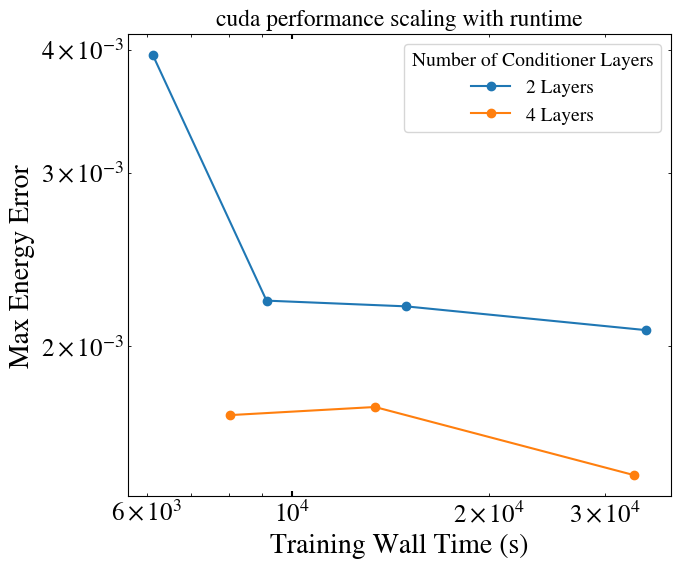

In [9]:
# plot eval_mean_error_mean as a function of n_orbits, with a separate line for each n_steps
device = 'cuda'
plt.figure(figsize=(7, 6))
for n_steps in df['model.conditioner.args.num_layers'].unique():
    subset = df[df['model.conditioner.args.num_layers'] == n_steps][df['device'] == device]
    plt.errorbar(subset['wall_time_s'], subset['eval_max_error_max'], marker='o', label=f'{n_steps} Layers')
plt.xlabel('Training Wall Time (s)', fontsize=20)
plt.ylabel('Max Energy Error', fontsize=20)
plt.yscale('log')
plt.xscale('log')
plt.legend(title='Number of Conditioner Layers')
plt.title(f'{device} performance scaling with runtime')
plt.show()

In [10]:
# Training time as a function of model size
# agg = df.groupby('model.complexity')
# plt.figure(figsize=(7, 6))
# for n_steps in df['model.n_layers'].unique():
#     subset = df[df['model.n_layers'] == n_steps]
#     plt.plot(subset['model.complexity'], subset['wall_time_s'], label=f'{n_steps} Layers', marker='o')
# plt.xlabel('Model Complexity', fontsize=20)
# plt.ylabel('Final Loss', fontsize=20)
# plt.yscale('log')
# plt.xscale('log')
# plt.legend(title='Number of Flow Layers')

In [11]:
agg_wall_time = df.groupby(['total_layers', 'device']).agg(
    wall_time_mean=('wall_time_s', 'mean'),
    wall_time_std=('wall_time_s', 'std'),
).reset_index()

In [12]:
agg_wall_time[agg_wall_time['device'] == device]

,total_layers,device,wall_time_mean,wall_time_std
0,64,cuda,6127.451984,NaN
1,128,cuda,8592.463940,774.088913
2,256,cuda,14149.753175,1085.565206
3,512,cuda,33984.951953,1031.157767


/tmp/ipykernel_2224041/3317969544.py:4: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  subset = df[df['model.conditioner.args.num_layers'] == n_steps][df['device'] == device]
/tmp/ipykernel_2224041/3317969544.py:4: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  subset = df[df['model.conditioner.args.num_layers'] == n_steps][df['device'] == device]


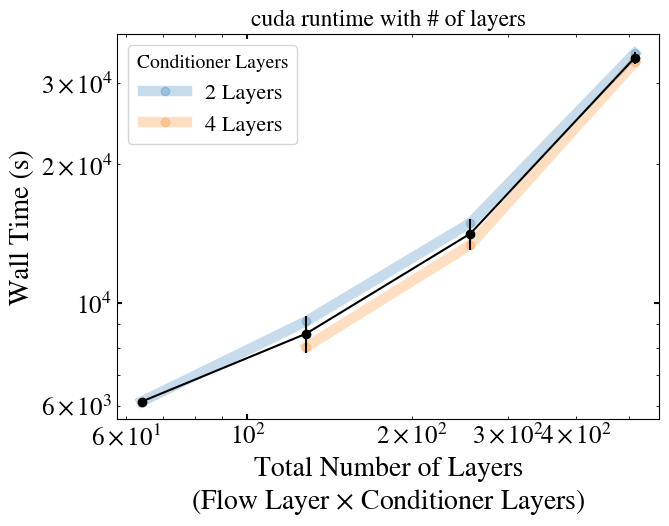

In [13]:
plt.figure(figsize=(7, 5))
device = 'cuda'
for n_steps in df['model.conditioner.args.num_layers'].unique():
    subset = df[df['model.conditioner.args.num_layers'] == n_steps][df['device'] == device]
    plt.errorbar(subset['total_layers'], subset['wall_time_s'], marker='o', label=f'{n_steps} Layers', zorder=0, lw=7.5, alpha=0.25)
plt.errorbar(agg_wall_time[agg_wall_time['device'] == device]['total_layers'], agg_wall_time[agg_wall_time['device'] == device]['wall_time_mean'],yerr=agg_wall_time[agg_wall_time['device'] == device]['wall_time_std'],  marker='o', c='k')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Total Number of Layers\n(Flow Layer $\\times$ Conditioner Layers)', fontsize=20)
plt.ylabel('Wall Time (s)', fontsize=20)
plt.legend(title='Conditioner Layers', fontsize=16)
plt.title(f'{device} runtime with # of layers')
plt.show()

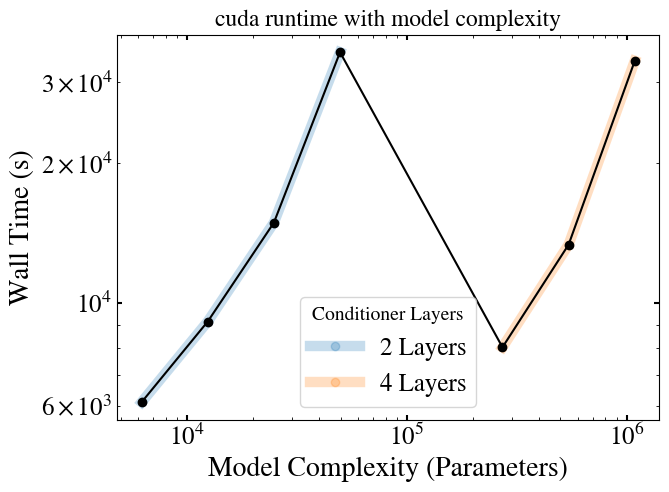

In [14]:
device = 'cuda'
device_mask = df['device'] == device
plt.figure(figsize=(7, 5))
for n_steps in df['model.conditioner.args.num_layers'].unique():
    subset = df[device_mask][df['model.conditioner.args.num_layers'] == n_steps]
    plt.errorbar(subset['model.complexity'], subset['wall_time_s'], marker='o', label=f'{n_steps} Layers', zorder=0, lw=7.5, alpha=0.25)
plt.plot(df[device_mask].sort_values(['model.complexity'])['model.complexity'], df[device_mask].sort_values(['model.complexity'])['wall_time_s'], marker='o', c='k')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Model Complexity (Parameters)', fontsize=20)
plt.ylabel('Wall Time (s)', fontsize=20)
plt.legend(title='Conditioner Layers', fontsize=18)
plt.title(f'{device} runtime with model complexity')
plt.show()

In [15]:
agg_error_eval = df.groupby('model.n_layers').agg(
    eval_mean=('eval_max_error_max', 'mean'),
    eval_std=('eval_max_error_max', 'std'),
).reset_index()

In [16]:
# # plot eval_mean_error_mean as a function of n_orbits, with a separate line for each n_steps
# plt.figure(figsize=(7, 6))
# for n_steps in df['model.n_layers'].unique():
#     subset = df[df['model.n_layers'] == n_steps]
#     plt.errorbar(subset['wall_time_s'], subset['eval_max_error_max'], marker='o', label=f'{n_steps} Layers')
# plt.xlabel('Training Wall Time (s)', fontsize=20)
# plt.ylabel('Max Energy Error', fontsize=20)
# plt.yscale('log')
# plt.xscale('log')
# plt.legend(title='Number of Flow Layers')

In [17]:
# plot eval_mean_error_mean as a function of n_orbits, with a separate line for each n_steps
# plt.figure(figsize=(7, 6))
# for n_steps in df['model.n_layers'].unique():
#     subset = df[df['model.n_layers'] == n_steps]
#     plt.errorbar(subset['model.conditioner.args.num_layers'], subset['tail_mean_loss'], yerr=subset['tail_std_loss'], marker='o', label=f'{n_steps} steps')
# plt.xlabel('Number of Orbits', fontsize=20)
# plt.ylabel('Final Loss', fontsize=20)
# plt.yscale('log')
# plt.xscale('log')
# plt.legend(title='Points per Training Orbit')

Do the models converge?


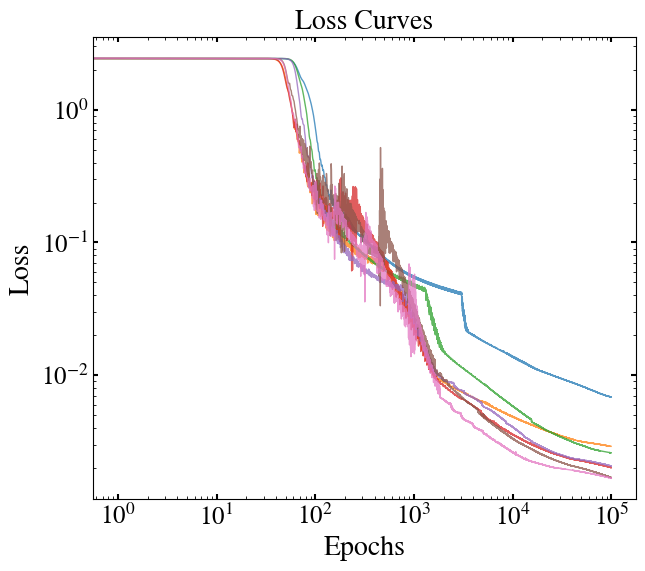

In [18]:
# from mat
plt.figure(figsize=(7, 6))

filepath = Path('results') / 'runs'
for run_id in df['run_id']:
    loss = np.load(filepath / run_id / 'loss_curve.npy')
    plt.loglog(loss, lw=1, alpha=0.75)
    #plt.errorbar(subset['data.n_orbits'], subset['tail_mean_loss'], yerr=subset['tail_std_loss'], marker='o', label=f'{n_steps} steps')
plt.xlabel('Epochs', fontsize=20)
plt.ylabel('Loss', fontsize=20)
plt.yscale('log')
plt.xscale('log')
plt.title('Loss Curves', fontsize=20)
plt.show()

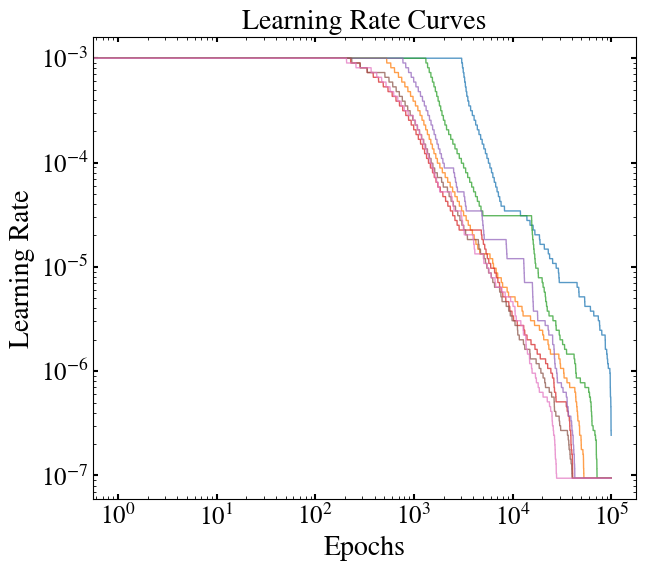

In [19]:
plt.figure(figsize=(7, 6))

for n_orbits in df['data.n_orbits'].unique():
    subset = df[df['data.n_orbits'] == n_orbits]
    for subset_id in subset['run_id']:
        filepath = Path('results') / 'runs'
        lr = np.load(filepath / subset_id / 'lr_curve.npy')
        plt.loglog(lr, lw=1, alpha=0.75)
    #plt.errorbar(subset['data.n_orbits'], subset['tail_mean_loss'], yerr=subset['tail_std_loss'], marker='o', label=f'{n_steps} steps')
plt.xlabel('Epochs', fontsize=20)
plt.ylabel('Learning Rate', fontsize=20)
plt.yscale('log')
plt.xscale('log')
plt.title('Learning Rate Curves', fontsize=20)
plt.show()

In [20]:
# filepath = Path('results') / 'runs'
# plt.figure(figsize=(8,6))
# for rundir in filepath.iterdir():
#     loss = np.load(rundir/'loss_curve.npy')
#     plt.loglog(loss)
# plt.xlabel('Epochs')
# plt.ylabel('Loss')

# Performance Analysis

$i$ = index of point along an orbit

$j$ = index of orbit

Better results by having more flow layers and fewer conditioner layers.

In [21]:
MAX_FLOW_LAYERS = 512
flow_layer_mask = df['model.n_layers'] <= MAX_FLOW_LAYERS

<>:42: SyntaxWarning: invalid escape sequence '\l'
<>:42: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_2224041/2852429817.py:42: SyntaxWarning: invalid escape sequence '\l'
  fig.colorbar(pcm, label='$\\log_{10} \left ( \left \\langle \max_i \left ( \\frac{\Delta H}{\\langle H \\rangle_{i}} \\right ) \\right \\rangle_{j} \\right ) $')


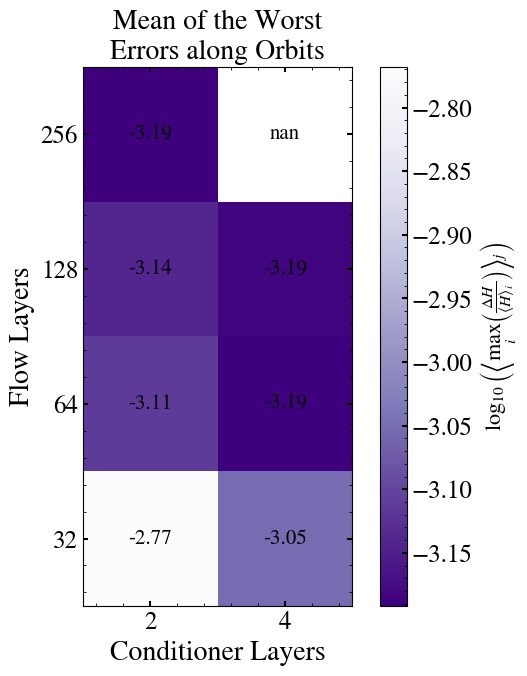

In [22]:
import numpy as np
import matplotlib.pyplot as plt

df_pivot = df[flow_layer_mask].pivot(
    index='model.n_layers',
    columns='model.conditioner.args.num_layers',
    values='eval_max_error_mean'
)

x = df_pivot.columns.to_numpy()   # n_steps
y = df_pivot.index.to_numpy()     # n_orbits
z = np.log10(df_pivot.to_numpy())


x_plot = np.log2(x)
y_plot = np.log2(y)

fig, ax = plt.subplots(figsize=(7,7))

pcm = ax.pcolormesh(x_plot, y_plot, z, shading='auto', cmap='Purples_r')

ax.set_xticks(x_plot)
ax.set_xticklabels(x)

ax.set_yticks(y_plot)
ax.set_yticklabels(y)

ax.set_aspect('equal')

# Add text inside each cell
for i in range(len(y)):
    for j in range(len(x)):
        ax.text(
            x_plot[j],
            y_plot[i],
            f"{z[i, j]:.2f}",   # format to 2 decimals
            ha='center',
            va='center',
            fontsize=15
        )

fig.colorbar(pcm, label='$\\log_{10} \left ( \left \\langle \max_i \left ( \\frac{\Delta H}{\\langle H \\rangle_{i}} \\right ) \\right \\rangle_{j} \\right ) $')

plt.xlabel("Conditioner Layers", fontsize=20)
plt.ylabel("Flow Layers", fontsize=20)
plt.title('Mean of the Worst\nErrors along Orbits', fontsize=20)

# plt.savefig('results/model_size_scaling.png')
plt.show()


<>:42: SyntaxWarning: invalid escape sequence '\l'
<>:42: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_2224041/395327803.py:42: SyntaxWarning: invalid escape sequence '\l'
  fig.colorbar(pcm, label='$\\log_{10} \left ( \max_j \left ( \max_i \left (\\frac{\Delta H}{\\langle H \\rangle_i} \\right ) \\right ) \\right )$')


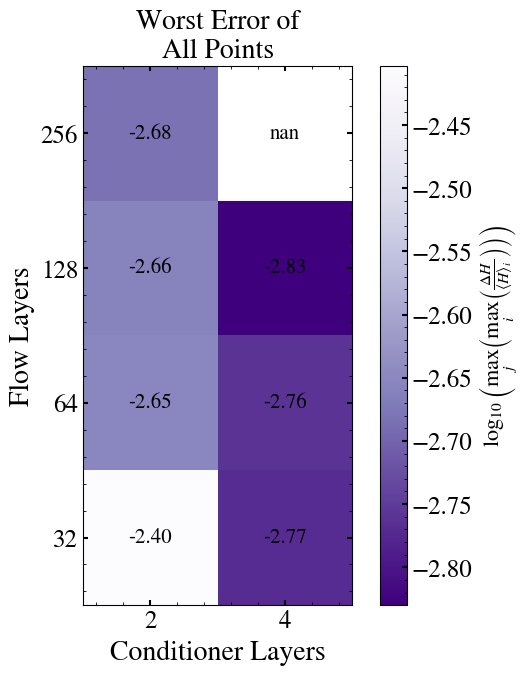

In [23]:
import numpy as np
import matplotlib.pyplot as plt

df_pivot = df[flow_layer_mask].pivot(
    index='model.n_layers',
    columns='model.conditioner.args.num_layers',
    values='eval_max_error_max'
)

x = df_pivot.columns.to_numpy()   # n_steps
y = df_pivot.index.to_numpy()     # n_orbits
z = np.log10(df_pivot.to_numpy())


x_plot = np.log2(x)
y_plot = np.log2(y)

fig, ax = plt.subplots(figsize=(7,7))

pcm = ax.pcolormesh(x_plot, y_plot, z, shading='auto', cmap='Purples_r')

ax.set_xticks(x_plot)
ax.set_xticklabels(x)

ax.set_yticks(y_plot)
ax.set_yticklabels(y)

ax.set_aspect('equal')

# Add text inside each cell
for i in range(len(y)):
    for j in range(len(x)):
        ax.text(
            x_plot[j],
            y_plot[i],
            f"{z[i, j]:.2f}",   # format to 2 decimals
            ha='center',
            va='center',
            fontsize=15
        )

fig.colorbar(pcm, label='$\\log_{10} \left ( \max_j \left ( \max_i \left (\\frac{\Delta H}{\\langle H \\rangle_i} \\right ) \\right ) \\right )$')

plt.xlabel("Conditioner Layers", fontsize=20)
plt.ylabel("Flow Layers", fontsize=20)
plt.title('Worst Error of\nAll Points', fontsize=20)

plt.show()


<>:42: SyntaxWarning: invalid escape sequence '\l'
<>:42: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_2224041/3588766922.py:42: SyntaxWarning: invalid escape sequence '\l'
  fig.colorbar(pcm, label='$\\log_{10} \left ( \left \\langle \left \\langle \\frac{\Delta H}{\\langle H \\rangle_{i}} \\right \\rangle_{i} \\right \\rangle_{j} \\right )$')


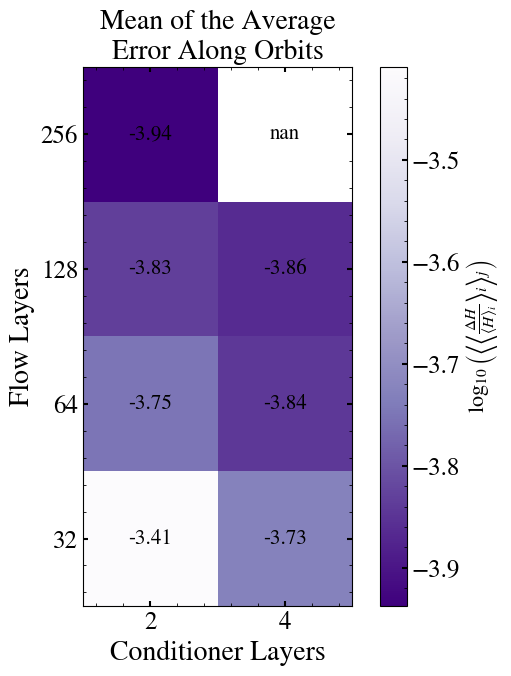

In [24]:
import numpy as np
import matplotlib.pyplot as plt

df_pivot = df[flow_layer_mask].pivot(
    index='model.n_layers',
    columns='model.conditioner.args.num_layers',
    values='eval_mean_error_mean'
)

x = df_pivot.columns.to_numpy()   # n_steps
y = df_pivot.index.to_numpy()     # n_orbits
z = np.log10(df_pivot.to_numpy())


x_plot = np.log2(x)
y_plot = np.log2(y)

fig, ax = plt.subplots(figsize=(7,7))

pcm = ax.pcolormesh(x_plot, y_plot, z, shading='auto', cmap='Purples_r')

ax.set_xticks(x_plot)
ax.set_xticklabels(x)

ax.set_yticks(y_plot)
ax.set_yticklabels(y)

ax.set_aspect('equal')

# Add text inside each cell
for i in range(len(y)):
    for j in range(len(x)):
        ax.text(
            x_plot[j],
            y_plot[i],
            f"{z[i, j]:.2f}",   # format to 2 decimals
            ha='center',
            va='center',
            fontsize=15
        )

fig.colorbar(pcm, label='$\\log_{10} \left ( \left \\langle \left \\langle \\frac{\Delta H}{\\langle H \\rangle_{i}} \\right \\rangle_{i} \\right \\rangle_{j} \\right )$')

plt.xlabel("Conditioner Layers", fontsize=20)
plt.ylabel("Flow Layers", fontsize=20)
plt.title('Mean of the Average\nError Along Orbits', fontsize=20)

plt.show()

<>:42: SyntaxWarning: invalid escape sequence '\l'
<>:42: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_2224041/1148069625.py:42: SyntaxWarning: invalid escape sequence '\l'
  fig.colorbar(pcm, label='$\\log_{10} \left ( \max_j \left ( \left \\langle \\frac{\Delta H}{\\langle H \\rangle_{i}} \\right \\rangle_{i} \\right ) \\right )$')


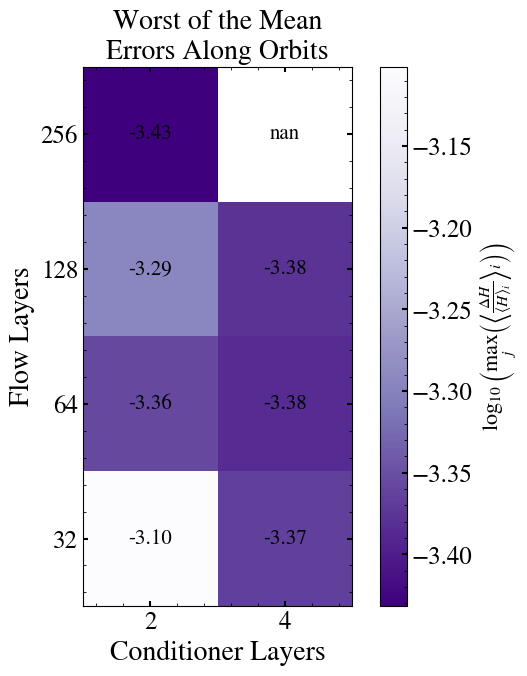

In [25]:
import numpy as np
import matplotlib.pyplot as plt

df_pivot = df[flow_layer_mask].pivot(
    index='model.n_layers',
    columns='model.conditioner.args.num_layers',
    values='eval_mean_error_max'
)

x = df_pivot.columns.to_numpy()   # n_steps
y = df_pivot.index.to_numpy()     # n_orbits
z = np.log10(df_pivot.to_numpy())


x_plot = np.log2(x)
y_plot = np.log2(y)

fig, ax = plt.subplots(figsize=(7,7))

pcm = ax.pcolormesh(x_plot, y_plot, z, shading='auto', cmap='Purples_r')

ax.set_xticks(x_plot)
ax.set_xticklabels(x)

ax.set_yticks(y_plot)
ax.set_yticklabels(y)

ax.set_aspect('equal')

# Add text inside each cell
for i in range(len(y)):
    for j in range(len(x)):
        ax.text(
            x_plot[j],
            y_plot[i],
            f"{z[i, j]:.2f}",   # format to 2 decimals
            ha='center',
            va='center',
            fontsize=15
        )

fig.colorbar(pcm, label='$\\log_{10} \left ( \max_j \left ( \left \\langle \\frac{\Delta H}{\\langle H \\rangle_{i}} \\right \\rangle_{i} \\right ) \\right )$')

plt.xlabel("Conditioner Layers", fontsize=20)
plt.ylabel("Flow Layers", fontsize=20)
plt.title('Worst of the Mean\nErrors Along Orbits', fontsize=20)

plt.show()

Looking at this plot, I think the curve are cutoff because the training is cut short. Longer training may produce something different.

<>:7: SyntaxWarning: invalid escape sequence '\l'
<>:7: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_2224041/3818469892.py:7: SyntaxWarning: invalid escape sequence '\l'
  plt.ylabel('$\left \\langle \max_i \left ( \\frac{\Delta H}{\\langle H \\rangle_{i}} \\right ) \\right \\rangle_{j}$', fontsize=25)


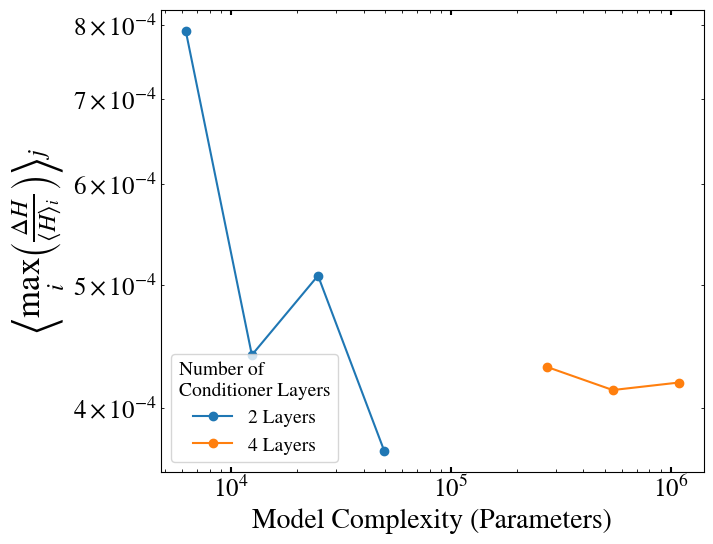

In [26]:
# plot eval_mean_error_mean as a function of n_orbits, with a separate line for each n_steps
plt.figure(figsize=(7, 6))
for n_steps in df['model.conditioner.args.num_layers'].unique():
    subset = df[df['model.conditioner.args.num_layers'] == n_steps]
    plt.errorbar(subset['model.complexity'], subset['eval_mean_error_max'], marker='o', label=f'{n_steps} Layers')
plt.xlabel('Model Complexity (Parameters)', fontsize=20)
plt.ylabel('$\left \\langle \max_i \left ( \\frac{\Delta H}{\\langle H \\rangle_{i}} \\right ) \\right \\rangle_{j}$', fontsize=25)
plt.yscale('log')
plt.xscale('log')
plt.legend(title='Number of\nConditioner Layers', loc='lower left')
plt.show()

### Worst Error of all points


<>:6: SyntaxWarning: invalid escape sequence '\m'
<>:6: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_2224041/1033603905.py:6: SyntaxWarning: invalid escape sequence '\m'
  plt.ylabel('$\max_j \left ( \max_i \left (\\frac{\Delta H}{\\langle H \\rangle_i} \\right ) \\right )$', fontsize=25)


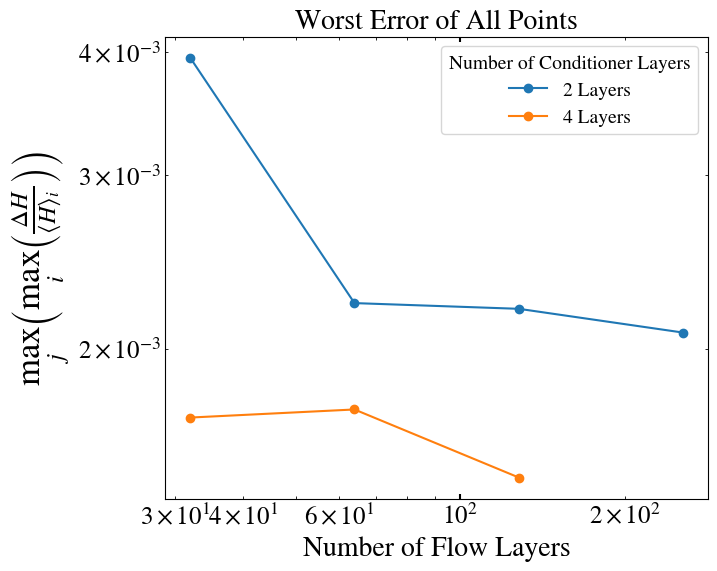

In [27]:
plt.figure(figsize=(7, 6))
for n_steps in df['model.conditioner.args.num_layers'].unique():
    subset = df[df['model.conditioner.args.num_layers'] == n_steps]
    plt.loglog(subset['model.n_layers'], subset['eval_max_error_max'], marker='o', label=f'{n_steps} Layers')
plt.xlabel('Number of Flow Layers', fontsize=20)
plt.ylabel('$\max_j \left ( \max_i \left (\\frac{\Delta H}{\\langle H \\rangle_i} \\right ) \\right )$', fontsize=25)
plt.legend(title='Number of Conditioner Layers')
plt.title('Worst Error of All Points', fontsize=20)
plt.show()

In [28]:
# from matplotlib.colors import BoundaryNorm
# from matplotlib.colors import ListedColormap

# # plot eval_mean_error_mean as a function of n_orbits, with a separate line for each n_steps
# fig, ax = plt.subplots(figsize=(7, 6))
# unique_conditioner_layers = df['model.conditioner.args.num_layers'].unique()
# unique_flow_layers = df['model.n_layers'].unique()
# conditioner_layer_colors = plt.cm.Blues(np.linspace(0.3, 0.9, len(unique_conditioner_layers)))
# flow_layer_colors = plt.cm.Reds(np.linspace(0.3, 0.9, len(unique_flow_layers)))
# for i, n_steps in enumerate(unique_conditioner_layers):
#     subset = df[df['model.conditioner.args.num_layers'] == n_steps]
#     ax.loglog(subset['model.complexity'], subset['eval_max_error_max'], label=f'{n_steps} Layers', c=conditioner_layer_colors[i])
# for i, n_steps in enumerate(unique_flow_layers):
#     subset = df[df['model.n_layers'] == n_steps]
#     ax.loglog(subset['model.complexity'], subset['eval_max_error_max'], label=f'{n_steps} Layers', c=flow_layer_colors[i])
# ax.set_xlabel('Number of Conditioner Layers', fontsize=20)
# ax.set_ylabel('$\max_j \left ( \max_i \left (\\frac{\Delta H}{\\langle H \\rangle_i} \\right ) \\right )$', fontsize=25)
# # plt.legend(title='Number of Flow Layers')
# cond_bounds = np.arange(len(unique_conditioner_layers) + 1) - 0.5
# flow_bounds = np.arange(len(unique_flow_layers) + 1) - 0.5

# cond_norm = BoundaryNorm(cond_bounds, ncolors=len(unique_conditioner_layers))
# flow_norm = BoundaryNorm(flow_bounds, ncolors=len(unique_flow_layers))

# sm_cond = plt.cm.ScalarMappable(cmap=ListedColormap(conditioner_layer_colors), norm=cond_norm)
# sm_flow = plt.cm.ScalarMappable(cmap=ListedColormap(flow_layer_colors), norm=flow_norm)
# sm_cond.set_array([])
# sm_flow.set_array([])

# cax_cond = fig.add_axes([0.92, 0.55, 0.02, 0.35])
# cax_flow = fig.add_axes([0.92, 0.10, 0.02, 0.35])

# cb_cond = fig.colorbar(sm_cond, cax=cax_cond, ticks=np.arange(len(unique_conditioner_layers)))
# cb_flow = fig.colorbar(sm_flow, cax=cax_flow, ticks=np.arange(len(unique_flow_layers)))

# cb_cond.set_ticklabels(unique_conditioner_layers)
# cb_cond.set_label('Conditioner Layers', fontsize=14)
# cb_flow.set_ticklabels(unique_flow_layers)
# cb_flow.set_label('Flow Layers', fontsize=14)
# ax.set_title('Worst Error of All Points', fontsize=20)
# plt.show()


### Mean of the average error along orbits

<>:6: SyntaxWarning: invalid escape sequence '\l'
<>:6: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_2224041/2546189128.py:6: SyntaxWarning: invalid escape sequence '\l'
  plt.ylabel('$\left \\langle \left \\langle \\frac{\Delta H}{\\langle H \\rangle_{i}} \\right \\rangle_{i} \\right \\rangle_{j}$', fontsize=25)


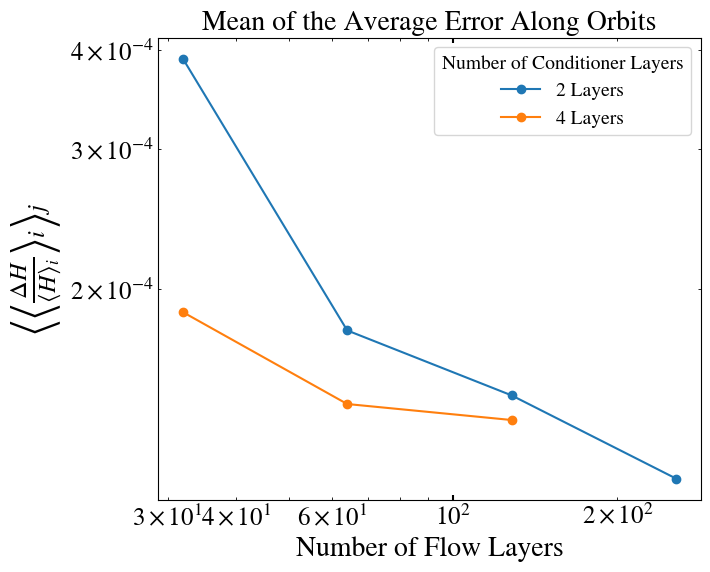

In [29]:
plt.figure(figsize=(7, 6))
for n_steps in df['model.conditioner.args.num_layers'].unique():
    subset = df[df['model.conditioner.args.num_layers'] == n_steps]
    plt.loglog(subset['model.n_layers'], subset['eval_mean_error_mean'], marker='o', label=f'{n_steps} Layers')
plt.xlabel('Number of Flow Layers', fontsize=20)
plt.ylabel('$\left \\langle \left \\langle \\frac{\Delta H}{\\langle H \\rangle_{i}} \\right \\rangle_{i} \\right \\rangle_{j}$', fontsize=25)
plt.legend(title='Number of Conditioner Layers')
plt.title('Mean of the Average Error Along Orbits', fontsize=20)
plt.show()

In [30]:
# from matplotlib.colors import BoundaryNorm
# from matplotlib.colors import ListedColormap

# # plot eval_mean_error_mean as a function of n_orbits, with a separate line for each n_steps
# fig, ax = plt.subplots(figsize=(7, 6))
# unique_conditioner_layers = df['model.conditioner.args.num_layers'].unique()
# unique_flow_layers = df['model.n_layers'].unique()
# conditioner_layer_colors = plt.cm.Blues(np.linspace(0.3, 0.9, len(unique_conditioner_layers)))
# flow_layer_colors = plt.cm.Reds(np.linspace(0.3, 0.9, len(unique_flow_layers)))
# for i, n_steps in enumerate(unique_conditioner_layers):
#     subset = df[df['model.conditioner.args.num_layers'] == n_steps]
#     ax.loglog(subset['total_layers'], subset['eval_mean_error_mean'], marker='o', label=f'{n_steps} Layers', c=conditioner_layer_colors[i])
# for i, n_steps in enumerate(unique_flow_layers):
#     subset = df[df['model.n_layers'] == n_steps]
#     ax.loglog(subset['total_layers'], subset['eval_mean_error_mean'], marker='o', label=f'{n_steps} Layers', c=flow_layer_colors[i])
# ax.set_xlabel('Number of Conditioner Layers', fontsize=20)
# ax.set_ylabel('$\left \\langle \left \\langle \\frac{H}{\\langle H \\rangle_{i}} \\right \\rangle_{i} \\right \\rangle_{j}$', fontsize=25)
# # plt.legend(title='Number of Flow Layers')
# cond_bounds = np.arange(len(unique_conditioner_layers) + 1) - 0.5
# flow_bounds = np.arange(len(unique_flow_layers) + 1) - 0.5

# cond_norm = BoundaryNorm(cond_bounds, ncolors=len(unique_conditioner_layers))
# flow_norm = BoundaryNorm(flow_bounds, ncolors=len(unique_flow_layers))

# sm_cond = plt.cm.ScalarMappable(cmap=ListedColormap(conditioner_layer_colors), norm=cond_norm)
# sm_flow = plt.cm.ScalarMappable(cmap=ListedColormap(flow_layer_colors), norm=flow_norm)
# sm_cond.set_array([])
# sm_flow.set_array([])

# cax_cond = fig.add_axes([0.92, 0.55, 0.02, 0.35])
# cax_flow = fig.add_axes([0.92, 0.10, 0.02, 0.35])

# cb_cond = fig.colorbar(sm_cond, cax=cax_cond, ticks=np.arange(len(unique_conditioner_layers)))
# cb_flow = fig.colorbar(sm_flow, cax=cax_flow, ticks=np.arange(len(unique_flow_layers)))

# cb_cond.set_ticklabels(unique_conditioner_layers)
# cb_cond.set_label('Conditioner Layers', fontsize=14)
# cb_flow.set_ticklabels(unique_flow_layers)
# cb_flow.set_label('Flow Layers', fontsize=14)
# ax.set_title('Mean of the Average Error Along Orbits', fontsize=20)
# plt.show()

<>:7: SyntaxWarning: invalid escape sequence '\l'
<>:7: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_2224041/4124320854.py:7: SyntaxWarning: invalid escape sequence '\l'
  plt.ylabel('$\left \\langle \left \\langle \\frac{\Delta H}{\\langle H \\rangle_{i}} \\right \\rangle_{i} \\right \\rangle_{j}$', fontsize=25)


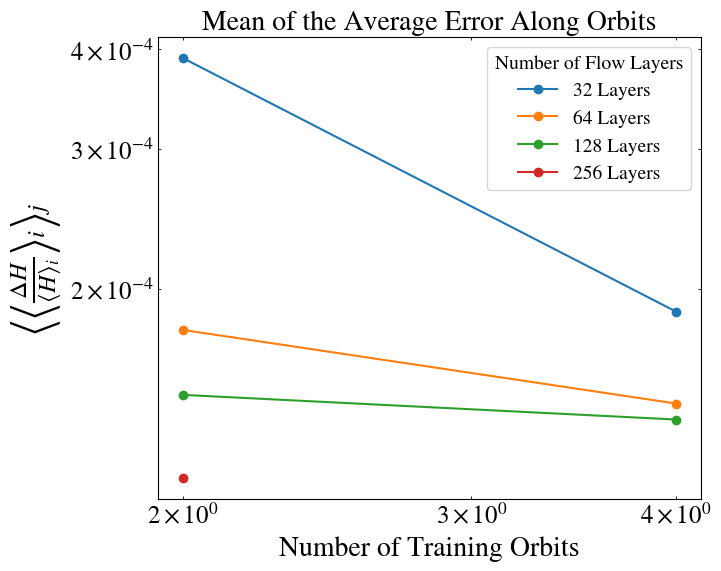

In [31]:
# plot eval_mean_error_mean as a function of n_orbits, with a separate line for each n_steps
plt.figure(figsize=(7, 6))
for n_steps in df['model.n_layers'].unique():
    subset = df[df['model.n_layers'] == n_steps]
    plt.loglog(subset['model.conditioner.args.num_layers'], subset['eval_mean_error_mean'], marker='o', label=f'{n_steps} Layers')
plt.xlabel('Number of Training Orbits', fontsize=20)
plt.ylabel('$\left \\langle \left \\langle \\frac{\Delta H}{\\langle H \\rangle_{i}} \\right \\rangle_{i} \\right \\rangle_{j}$', fontsize=25)
plt.legend(title='Number of Flow Layers')
plt.title('Mean of the Average Error Along Orbits', fontsize=20)
plt.show()

### Mean of the worst errors along orbits

<>:6: SyntaxWarning: invalid escape sequence '\l'
<>:6: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_2224041/756590768.py:6: SyntaxWarning: invalid escape sequence '\l'
  plt.ylabel('$\left \\langle \max_i \left ( \\frac{\Delta H}{\\langle H \\rangle_{i}} \\right ) \\right \\rangle_{j}$', fontsize=25)


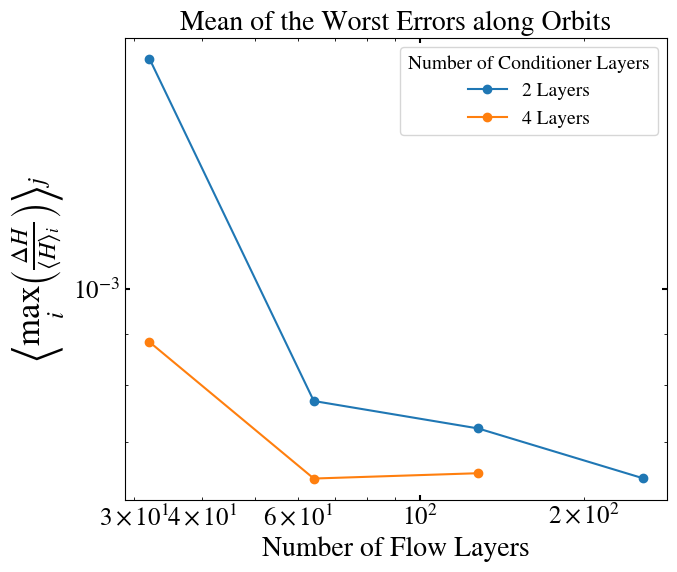

In [32]:
plt.figure(figsize=(7, 6))
for n_steps in df['model.conditioner.args.num_layers'].unique():
    subset = df[df['model.conditioner.args.num_layers'] == n_steps]
    plt.loglog(subset['model.n_layers'], subset['eval_max_error_mean'], marker='o', label=f'{n_steps} Layers')
plt.xlabel('Number of Flow Layers', fontsize=20)
plt.ylabel('$\left \\langle \max_i \left ( \\frac{\Delta H}{\\langle H \\rangle_{i}} \\right ) \\right \\rangle_{j}$', fontsize=25)
plt.legend(title='Number of Conditioner Layers')
plt.title('Mean of the Worst Errors along Orbits', fontsize=20)
plt.show()

<>:6: SyntaxWarning: invalid escape sequence '\l'
<>:6: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_2224041/357247177.py:6: SyntaxWarning: invalid escape sequence '\l'
  plt.ylabel('$\left \\langle \max_i \left ( \\frac{\Delta H}{\\langle H \\rangle_{i}} \\right ) \\right \\rangle_{j}$', fontsize=25)


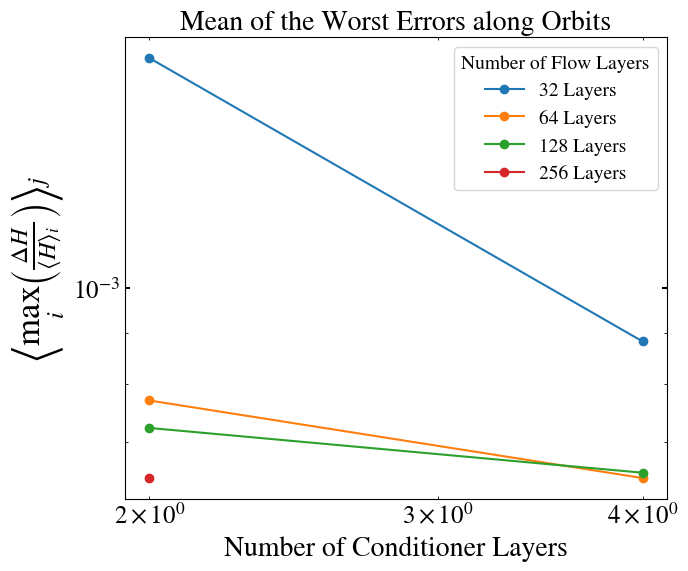

In [33]:
plt.figure(figsize=(7, 6))
for n_steps in df['model.n_layers'].unique():
    subset = df[df['model.n_layers'] == n_steps]
    plt.loglog(subset['model.conditioner.args.num_layers'], subset['eval_max_error_mean'], marker='o', label=f'{n_steps} Layers')
plt.xlabel('Number of Conditioner Layers', fontsize=20)
plt.ylabel('$\left \\langle \max_i \left ( \\frac{\Delta H}{\\langle H \\rangle_{i}} \\right ) \\right \\rangle_{j}$', fontsize=25)
plt.legend(title='Number of Flow Layers')
plt.title('Mean of the Worst Errors along Orbits', fontsize=20)
plt.show()

### Worst of the mean errors along orbits

<>:6: SyntaxWarning: invalid escape sequence '\m'
<>:6: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_2224041/1519251910.py:6: SyntaxWarning: invalid escape sequence '\m'
  plt.ylabel('$ \max_j \left ( \left \\langle \\frac{\Delta H}{\\langle H \\rangle_{i}} \\right \\rangle_{i} \\right )$', fontsize=25)


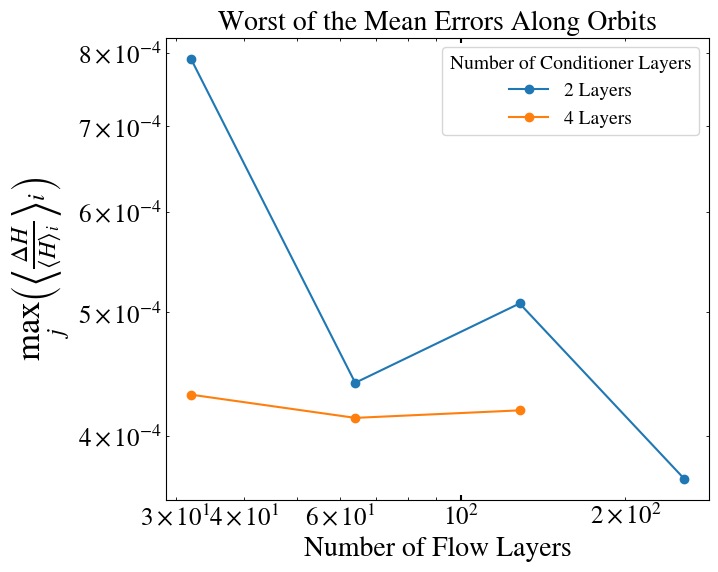

In [34]:
plt.figure(figsize=(7, 6))
for n_steps in df['model.conditioner.args.num_layers'].unique():
    subset = df[df['model.conditioner.args.num_layers'] == n_steps]
    plt.loglog(subset['model.n_layers'], subset['eval_mean_error_max'], marker='o', label=f'{n_steps} Layers')
plt.xlabel('Number of Flow Layers', fontsize=20)
plt.ylabel('$ \max_j \left ( \left \\langle \\frac{\Delta H}{\\langle H \\rangle_{i}} \\right \\rangle_{i} \\right )$', fontsize=25)
plt.legend(title='Number of Conditioner Layers')
plt.title('Worst of the Mean Errors Along Orbits', fontsize=20)
plt.show()

<>:6: SyntaxWarning: invalid escape sequence '\m'
<>:6: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_2224041/1801725277.py:6: SyntaxWarning: invalid escape sequence '\m'
  plt.ylabel('$ \max_j \left ( \left \\langle \\frac{\Delta H}{\\langle H \\rangle_{i}} \\right \\rangle_{i} \\right )$', fontsize=25)


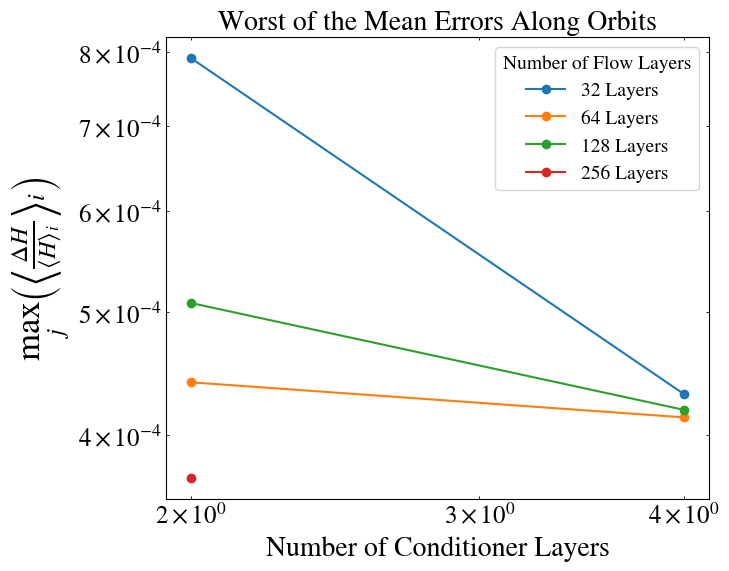

In [35]:
plt.figure(figsize=(7, 6))
for n_steps in df['model.n_layers'].unique():
    subset = df[df['model.n_layers'] == n_steps]
    plt.loglog(subset['model.conditioner.args.num_layers'], subset['eval_mean_error_max'], marker='o', label=f'{n_steps} Layers')
plt.xlabel('Number of Conditioner Layers', fontsize=20)
plt.ylabel('$ \max_j \left ( \left \\langle \\frac{\Delta H}{\\langle H \\rangle_{i}} \\right \\rangle_{i} \\right )$', fontsize=25)
plt.legend(title='Number of Flow Layers')
plt.title('Worst of the Mean Errors Along Orbits', fontsize=20)
plt.show()